In [1]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import random

## renders plotly properly in a html instance. 
#import plotly.io as pio
#pio.renderers.default = "notebook"


In [3]:
## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [4]:
## get embeddings for each view and normalize it 
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)

## CREATE VIEWS OF THE DATASET THAT ARE REPRESENTATIVE OF GEOGRAPHICAL LOCATIONS
## NOTE : Mantasandy is being excluded from further analysis because
## it only has 3 images inside the folder. 
view_GAM = wp_view.match(
    F("subregion")=="GAM"
)
view_FRIWEN = wp_view.match(
    F("subregion")=="FRIWEN"
)
view_MANTASANDY = wp_view.match(
    F("subregion")=="MANTASANDY"
)
view_UM = wp_view.match(
    F("subregion")=="UM"
)
gam_emb = view_GAM.values('full_embeddings')
friwen_emb = view_FRIWEN.values('full_embeddings')
um_emb = view_UM.values('full_embeddings')

norm_gam_emb = normalize(gam_emb)
norm_friwen_emb = normalize(friwen_emb)
norm_um_emb = normalize(um_emb)

print("Number of images per geographical location")
print(f"WP- GAM: {len(view_GAM)}")
print(f"WP - FRIWEN: {len(view_FRIWEN)}")
print(f"WP - MANTASANDY: {len(view_MANTASANDY)}")
print(f"WP -UM: {len(view_UM)}")
print(f"NC: {len(nc_view)}")
print(f"WP (total): {len(wp_view)}")

datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm,
            'WP_GAM':norm_gam_emb,
            'WP_friwen':norm_friwen_emb,
            'WP_mant':norm_um_emb}



Number of images per geographical location
WP- GAM: 512
WP - FRIWEN: 779
WP - MANTASANDY: 3
WP -UM: 745
NC: 716
WP (total): 2039


In [79]:
session = fo.launch_app(dataset,auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


###  Filter field labels

#### Background Complexity

For each object, we have several fields manually created and annotated describing the objects. 

At this section, we are looking if the ID estimation given by MLE has a correlation with manually annotated characteristics, in specific, the background characteristic over the object.

In [19]:
## creates a function
def flatten_nested_embeddings(nested_embeddings):
    """
    Returns a embeddings of shape:
        Total detections, 1024.
    """
    # flatten and avoid null/none values
    final_list = [
        emb for sublist in nested_embeddings 
        if sublist is not None 
        for emb in sublist 
        if emb is not None
    ]
    return np.vstack(final_list)

## compute the ID given by the background diversity:
## construct functions
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")
    
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        dict of MLE distances for each neighboor
    """
    def compute(dataset, 
                n_neighboors: int,
                n_jobs: int = 1):
        """
        Returns a float containing the intrinsic measure. 
        """
        mlea = skdim.id.MLE().fit_transform(X = dataset,
                                                n_neighbors = n_neighboors,
                                                n_jobs = 1)
        return mlea 
        
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                mlea = compute(dataset,
                               n_neighboors = k)
                results[k] = mlea
        else:
            mlea = compute(dataset,
                           n_neighboors = k)
            results[k] = mlea
    return results


In [6]:
from fiftyone import ViewField as F

# Filter detections in the 'audit' field
medium_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))

3347
3342
467


Text(0.5, 0.98, 'High complexity background')

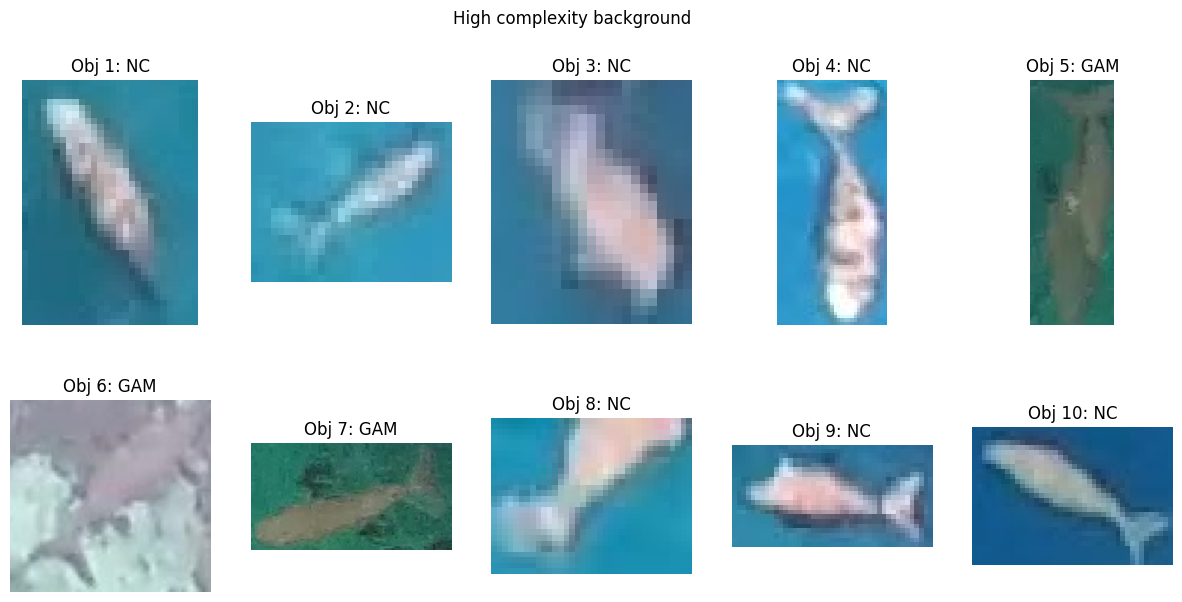

In [50]:
import PIL

patches_view = high_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("High complexity background")

Text(0.5, 0.98, 'Medium complexity background')

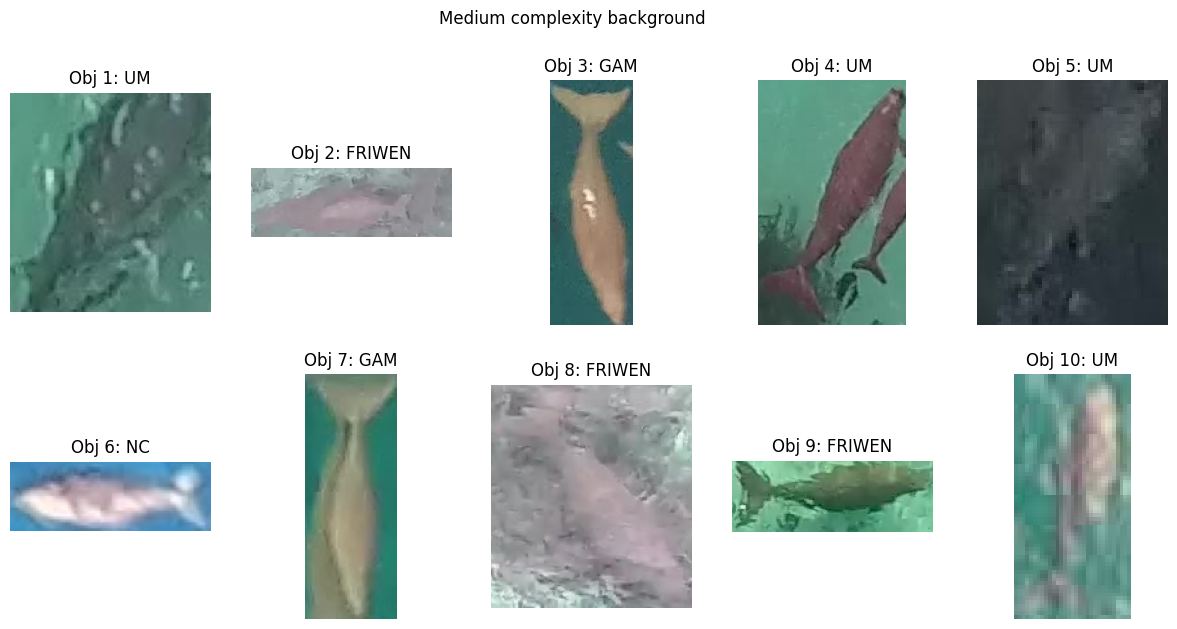

In [46]:

patches_view = medium_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("Medium complexity background")

Text(0.5, 0.98, 'Low complexity background')

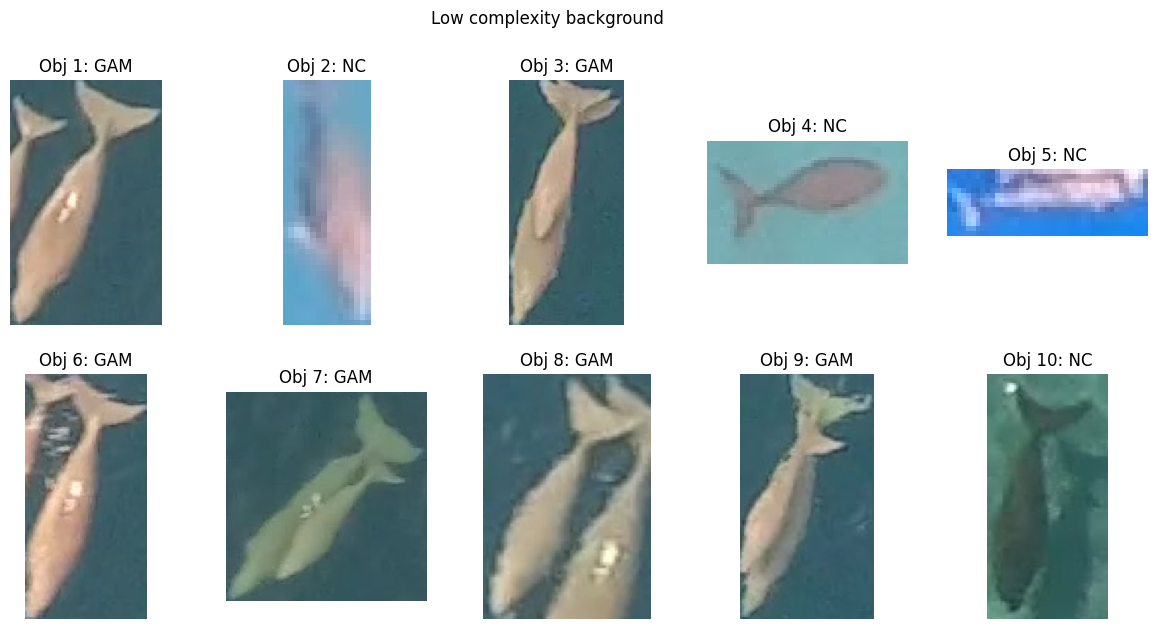

In [47]:
patches_view = low_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("Low complexity background")

In [20]:
## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


Patch Embeddings size of each dataset:
LOW size:(467, 1024)
MEDIUM: (3343, 1024)
HIGH: (3347, 1024)


In [21]:
## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


Running:LOW
Running:MEDIUM
Running:HIGH


In [22]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

### Evaluating complexity for Target Region

West Papua

In [56]:
from fiftyone import ViewField as F

# Filter detections in the 'audit' field
medium_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))

579
2727
304


In [52]:
wp_view.count('ground_truth.detections')

3615

In [77]:
## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

## filter the medium to match more and less the number of other samples
idx = np.random.choice(emb_medium_bg_complex.shape[0], size=500, replace=False)
emb_medium_bg_complex = emb_medium_bg_complex[idx]


print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


Patch Embeddings size of each dataset:
LOW size:(304, 1024)
MEDIUM: (500, 1024)
HIGH: (570, 1024)
Running:LOW
Running:MEDIUM
Running:HIGH


In [78]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="West Papua - ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

In [70]:
wp_view_flpn = wp_view.match(
    F('flight_plan').starts_with('FPLAN'))
wp_view_man = wp_view.match(
    F('flight_plan').starts_with('MAN')
)

# Filter detections in the 'audit' field
medium_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))


## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


570
2684
304
Patch Embeddings size of each dataset:
LOW size:(304, 1024)
MEDIUM: (2685, 1024)
HIGH: (570, 1024)
Running:LOW
Running:MEDIUM
Running:HIGH


In [71]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="West Papua - ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

In [66]:
pd.Series(dataset.values('flight_plan')).unique()

<ArrowStringArray>
['GH', 'FPLAN', 'MAN']
Length: 3, dtype: str

### --------------------

In [ ]:
from pathlib import Path
import random
filepath = dataset.values("filepath")

## iter and extract
extract_first_word = []
for fil in filepath:
    extract_first_word.append(Path(fil).stem.split("_")[0])

len(extract_first_word)

In [70]:
data = random.choices(extract_first_word, k=10)

# def contains_gh(word):
#     return bool(re.search(r"GH", word))

# result = [contains_gh(word) for word in data]
# print(result)



def map_to_gh(word):
    return "GH" if re.search(r"^GH", word) else word

result = list(map(map_to_gh, extract_first_word))
print("Unique labels found it.")
print(pd.Series(result).unique())


Unique labels found it.
<ArrowStringArray>
['GH', 'FPLAN', 'MAN']
Length: 3, dtype: str


In [ ]:
import re 
## add field to dataset

filepath = dataset.values("filepath")

## iter and extract
## very simple extraction of the first sentence 
extract_first_word = []
for fil in filepath:
    extract_first_word.append(Path(fil).stem.split("_")[0])

## we convert everything that is GH as from New Calodonia, and therefore we rename if to GH
def map_to_gh(word):
    return "GH" if re.search(r"^GH", word) else word

result = list(map(map_to_gh, extract_first_word))
print("Unique labels found it.")
print(pd.Series(result).unique())


# create a mapping dictionary: {filepath: tag}
# We use absolute filepaths to be 100% safe
filepaths = dataset.values("filepath")
tag_map = dict(zip(filepaths, result))

# 3. Add the field to the dataset (if it doesn't exist yet)
if not dataset.has_sample_field("flight_plan"):
    dataset.add_sample_field("flight_plan", fo.StringField)

# 4. Bulk update the values
dataset.set_values("flight_plan", tag_map, key_field="filepath")



Unique labels found it.
<ArrowStringArray>
['GH', 'FPLAN', 'MAN']
Length: 3, dtype: str


In [74]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 24, 19, 11, 8, 395000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
     